In [1]:
%pwd

'/home/tzuhsuan/GitHub/QFoam/High-fidelity-Rydberg-control-Z-gates-with-time-optimal-pulses/Manuscript-figures'

In [2]:
import os
import glob
import time
from IPython.display import clear_output

from qutip import *
import math

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

from rdquantum.pulse_shape import Saffman_shape
from rdquantum.fidelity import fidelity
from rdquantum.optimizer.de import de

# plt.rcParams["figure.figsize"] = [8, 5]
plt.rcParams["figure.figsize"] = [9, 3.5]
plt.rcParams["figure.autolayout"] = True
plt.rcParams["axes.edgecolor"] = "black"
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.linewidth"] = 2.50
plt.figure(dpi=1200)

<Figure size 10800x4200 with 0 Axes>

<Figure size 10800x4200 with 0 Axes>

In [3]:
# Gaussian500_53S_5L_BrrX
brr = [50, 75, 100, 125, 150, 200, 250, 300, 400, 500]
brr_op_fidelity = []
brr_op_fidelity_r2 = []
brr_op_tgate = []
root_dir = "Gaussian500_53S_5L_BrrX"
data_dir_prefix = "Gaussian500_53S_5L_Brr"
for i in range(len(brr)):
    opinfo_file = "../{}/{}{}/out.npz".format(root_dir, data_dir_prefix, brr[i])
    opinfo_r2_file = "../{}/{}{}/out_r2.npz".format(root_dir, data_dir_prefix, brr[i])
    oppulse_file = "../{}/{}{}/out-op_pulse.npz".format(root_dir, data_dir_prefix, brr[i])
    opinfo = np.load(opinfo_file, allow_pickle=True)
    opinfo_r2 = np.load(opinfo_r2_file, allow_pickle=True)
    oppulse = np.load(oppulse_file, allow_pickle=True)
    
    brr_op_fidelity.append(1-opinfo["op_fidelity"].item(0))
    brr_op_fidelity_r2.append(1-opinfo_r2["op_fidelity"].item(0))
    brr_op_tgate.append(oppulse['T_gate'].item(0))
    
# Gaussian500_DeltaX
deltaamp = [1, 2, 3, 6, 8]
delta_op_fidelity = []
delta_op_fidelity_r2 = []
delta_op_tgate = []
root_dir = "Gaussian500_DeltaX"
data_dir_prefix = "Gaussian500_Delta"
for i in range(len(deltaamp)):
    opinfo_file = "../{}/{}{}/out.npz".format(root_dir, data_dir_prefix, deltaamp[i])
    opinfo_r2_file = "../{}/{}{}/out_r2.npz".format(root_dir, data_dir_prefix, deltaamp[i])
    oppulse_file = "../{}/{}{}/out-op_pulse.npz".format(root_dir, data_dir_prefix, deltaamp[i])
    opinfo = np.load(opinfo_file, allow_pickle=True)
    opinfo_r2 = np.load(opinfo_r2_file, allow_pickle=True)
    oppulse = np.load(oppulse_file, allow_pickle=True)
    
    delta_op_fidelity.append(1-opinfo["op_fidelity"].item(0))
    delta_op_fidelity_r2.append(1-opinfo_r2["op_fidelity"].item(0))
    delta_op_tgate.append(oppulse['T_gate'].item(0))
    
# Popevo - Gaussian500_53S_5L_BrrX
brr_pop = [50, 75, 100, 125, 150, 200, 250, 300, 400, 500]
brr_init01_r2_Pr2 = []
brr_init11_r2_Pr2 = []
brr_PD5L = []
brr_PD6L = []
root_dir = "Gaussian500_53S_5L_BrrX"
data_dir_prefix = "Gaussian500_53S_5L_Brr"
for i in range(len(brr_pop)):
    out_init01_file = "../{}/{}{}/out_init01.npz".format(root_dir, data_dir_prefix, brr_pop[i])
    out_init11_file = "../{}/{}{}/out_init11.npz".format(root_dir, data_dir_prefix, brr_pop[i])
    out_init01_r2_file = "../{}/{}{}/out_init01_r2.npz".format(root_dir, data_dir_prefix, brr_pop[i])
    out_init11_r2_file = "../{}/{}{}/out_init11_r2.npz".format(root_dir, data_dir_prefix, brr_pop[i])
    
    out_init01 = np.load(out_init01_file, allow_pickle=True)
    out_init11 = np.load(out_init11_file, allow_pickle=True)
    out_init01_r2 = np.load(out_init01_r2_file, allow_pickle=True)
    out_init11_r2 = np.load(out_init11_r2_file, allow_pickle=True)
    
    brr_init01_r2_Pr2.append(out_init01_r2["P0r'"].item(-1))
    brr_init11_r2_Pr2.append(out_init11_r2["Pr'r'"].item(-1))
    
# Popevo - Gaussian500_DeltaX
delta_pop = [1, 2, 3, 6, 8]
delta_init01_r2_Pr2 = []
delta_init11_r2_Pr2 = []
delta_PD5L = []
delta_PD6L = []
root_dir = "Gaussian500_DeltaX"
data_dir_prefix = "Gaussian500_Delta"
for i in range(len(delta_pop)):
    out_init01_file = "../{}/{}{}/out_init01.npz".format(root_dir, data_dir_prefix, delta_pop[i])
    out_init11_file = "../{}/{}{}/out_init11.npz".format(root_dir, data_dir_prefix, delta_pop[i])
    out_init01_r2_file = "../{}/{}{}/out_init01_r2.npz".format(root_dir, data_dir_prefix, delta_pop[i])
    out_init11_r2_file = "../{}/{}{}/out_init11_r2.npz".format(root_dir, data_dir_prefix, delta_pop[i])
    
    out_init01 = np.load(out_init01_file, allow_pickle=True)
    out_init11 = np.load(out_init11_file, allow_pickle=True)
    out_init01_r2 = np.load(out_init01_r2_file, allow_pickle=True)
    out_init11_r2 = np.load(out_init11_r2_file, allow_pickle=True)
    
    delta_init01_r2_Pr2.append(out_init01_r2["P0r'"].item(-1))
    delta_init11_r2_Pr2.append(out_init11_r2["Pr'r'"].item(-1))

In [4]:
print(brr_op_fidelity)
print(brr_op_fidelity_r2)
print(brr_op_tgate)
print(delta_op_fidelity)
print(delta_op_fidelity_r2)
print(delta_op_tgate)
print(brr_init01_r2_Pr2)
print(brr_init11_r2_Pr2)
print(delta_init01_r2_Pr2)
print(delta_init11_r2_Pr2)

[0.0007991550177628426, 0.0010255557220085754, 0.0013347313355560608, 0.0016832289301631498, 0.002048418154855458, 0.0032495326715573647, 0.0031639005122613417, 0.0031016015571716515, 0.003015891401200177, 0.0029598262658802055]
[0.0011084784960047056, 0.001274741848670491, 0.0015939428212516926, 0.0019973115452917023, 0.0024299530832531113, 0.0037525732160168523, 0.003629578979144399, 0.0035429592524680587, 0.0034229053922467667, 0.0033442391129654414]
[0.19386164338898954, 0.12728038335807385, 0.10395796852857933, 0.09271147863773202, 0.07714820208823936, 0.7462587120116003, 0.6799828965459596, 0.6391544602792396, 0.5794941956146293, 0.537289118132945]
[0.0016204665995972478, 0.0010035374979504574, 0.0009443050056114899, 0.0011930272740527936, 0.0014248670660639284]
[0.001946009445106145, 0.0013645886871667123, 0.0014215729470083982, 0.0020388363814378696, 0.002502750681102839]
[0.4012775411999071, 0.5212875442537913, 0.700209508435512, 1.143118562375786, 1.3965230908287203]
[-8.8231

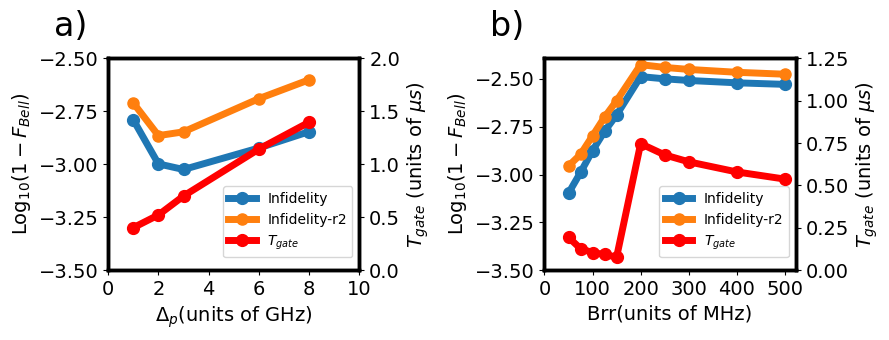

In [5]:
fig, axs = plt.subplots(1,2)

axa = axs[1]
axb = axs[0]
# axc = axs[1,0]
# axd = axs[1,1]
# times = np.linspace(0.0, T_gate, 100)

#axa
axap = axa.plot(brr, np.log10(brr_op_fidelity), '-o', markersize=8.5, linewidth=5, label="Infidelity")
axap2 = axa.plot(brr, np.log10(brr_op_fidelity_r2), '-o', markersize=8, linewidth=5, label="Infidelity-r2")
axat = axa.twinx()
axatp = axat.plot(brr, brr_op_tgate, '-o', markersize=8.5, linewidth=5, label=r"$T_{gate}$", color='r')
axald = axap + axap2 + axatp
# axald = axap + axatp
axalb = [lb.get_label() for lb in axald]
axa.legend(axald, axalb, bbox_to_anchor=(1.0, .43), fontsize=10)

axa.set_xlabel('Brr' '(units of MHz)', fontsize=14)
axa.set_ylabel('Log' r'$_{10}$' r'$(1-F_{Bell})$', fontsize=14)
axat.set_ylabel(r'$T_{gate}$' ' (units of ' r'$\mu s$' ')', fontsize=14)

xinterval = np.arange(0, 520, 100)
y1interval = np.arange(-3.5, -2.25, 0.25)
y2interval = np.arange(0, 1.5, 0.25)
axa.set_xticks(xinterval)
axa.set_yticks(y1interval)
axat.set_yticks(y2interval)
axa.tick_params(axis='x', labelsize=14)
axa.tick_params(axis='y', labelsize=14)
axat.tick_params(axis='y', labelsize=14)

axa.set_title('b)', x=-0.15, pad=16, fontsize=24)

#axb
axbp = axb.plot(deltaamp, np.log10(delta_op_fidelity), '-o', markersize=8.5, linewidth=5, label="Infidelity")
axbp2 = axb.plot(deltaamp, np.log10(delta_op_fidelity_r2), '-o', markersize=8, linewidth=5, label="Infidelity-r2")
axbt = axb.twinx()
axbtp = axbt.plot(deltaamp, delta_op_tgate, '-o', markersize=8.5, linewidth=5, label=r"$T_{gate}$", color='r')
axbld = axbp + axbp2 + axbtp
# axbld = axbp + axbtp
axblb = [lb.get_label() for lb in axbld]
axb.legend(axbld, axblb, bbox_to_anchor=(1.0, .43), fontsize=10)

axb.set_xlabel(r'$\Delta_{p}$' '(units of GHz)', fontsize=14)
axb.set_ylabel('Log' r'$_{10}$' r'$(1-F_{Bell})$', fontsize=14)
axbt.set_ylabel(r'$T_{gate}$' ' (units of ' r'$\mu s$' ')', fontsize=14)

xinterval = np.arange(0, 11, 2)
y1interval = np.arange(-3.5, -2.25, 0.25)
y2interval = np.arange(0, 2.1, 0.5)
axb.set_xticks(xinterval)
axb.set_yticks(y1interval)
axbt.set_yticks(y2interval)
axb.tick_params(axis='x', labelsize=14)
axb.tick_params(axis='y', labelsize=14)
axbt.tick_params(axis='y', labelsize=14)

axb.set_title('a)', x=-0.15, pad=16, fontsize=24)

# #axc
# axcp = axc.plot(brr_pop, brr_init01_r2_Pr2, '-o', markersize=8, linewidth=5, label="Pr'")
# axcp2 = axc.plot(brr_pop, brr_init11_r2_Pr2, '-o', markersize=8, linewidth=5, label="Pr'r'")
# axcld = axcp + axcp2
# axclb = [lb.get_label() for lb in axcld]
# axc.legend(axcld, axclb, bbox_to_anchor=(1.02, .55), fontsize=10)

# axc.set_xlabel('Brr' '(units of MHz)', fontsize=12)
# # axc.set_ylim(-9, 1)
# axc.set_ylabel(r'$log_{10}$' '(population)', fontsize=12)

# axc.set_title('c)', loc='left', pad=10)

# #axc
# axdp = axd.plot(delta_pop, delta_init01_r2_Pr2, '-o', markersize=8, linewidth=5, label="Pr'")
# axdp2 = axd.plot(delta_pop, delta_init11_r2_Pr2, '-o', markersize=8, linewidth=5, label="Pr'r'")
# axdld = axdp + axcp2
# axdlb = [lb.get_label() for lb in axdld]
# axd.legend(axdld, axdlb, bbox_to_anchor=(.635, .55), fontsize=10)

# axd.set_xlabel(r'$\Delta_{p}$' '(units of GHz)', fontsize=12)
# # axc.set_ylim(-9, 1)
# axd.set_ylabel(r'$log_{10}$' '(population)', fontsize=12)

# axd.set_title('d)', loc='left', pad=10)

plt.savefig('fig2_r2.png', dpi=1200)